In [1]:
# Import necessary packages
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from pathlib import Path

In [2]:
# Define the folder containing your CSV files
folder = Path("../mds_distortion_chunks")

# Read all CSV files in the folder and concatenate into one DataFrame
df = pd.concat(
    (
        pd.read_csv(f)  # read each CSV file into a DataFrame
        for f in folder.glob("*.csv")  # iterate over all .csv files in the folder
    ),
    ignore_index=True  # reset index after concatenation
)

df.to_csv('distortion_analysis.csv',index=False)

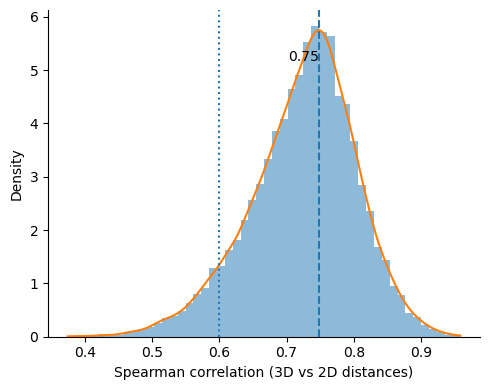

In [3]:
# Extract Spearman correlation values, dropping any missing entries
vals = df['spearman_r'].dropna().values

# Create figure
plt.figure(figsize=(5,4))

# Plot histogram (normalized to density so it aligns with KDE scale)
plt.hist(vals, bins=50, density=True, alpha=0.5)

# Compute kernel density estimate (KDE) from the data
kde = gaussian_kde(vals)

# Create a smooth grid of x values spanning the data range
x_grid = np.linspace(vals.min(), vals.max(), 500)

# Evaluate KDE on the grid
kde_vals = kde(x_grid)

# Plot KDE curve
plt.plot(x_grid, kde_vals)

# Identify x-position of maximum density (mode of distribution)
peak_x = x_grid[np.argmax(kde_vals)]

# Draw vertical dashed line at the peak
plt.axvline(peak_x, linestyle='--')

# Annotate the peak value slightly below the top of the KDE curve
plt.text(
    peak_x, 
    max(kde_vals) * 0.9, 
    f'{peak_x:.2f}', 
    ha='right'
)

# Optional: add vertical reference line at threshold (e.g., 0.6)
plt.axvline(0.6, linestyle=':')

# Axis labels
plt.xlabel('Spearman correlation (3D vs 2D distances)')
plt.ylabel('Density')

# Clean up plot aesthetics by removing top/right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot
plt.tight_layout()
plt.show()

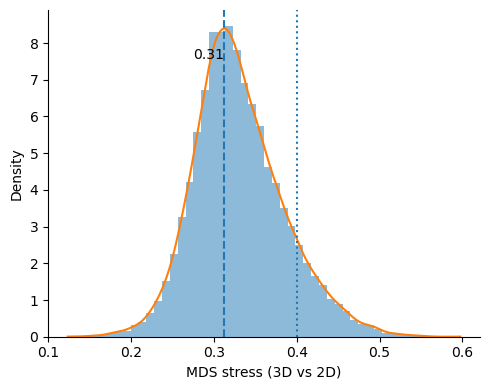

In [4]:
# Extract MDS stress values, removing missing entries
vals = df['stress'].dropna().values

# Create figure
plt.figure(figsize=(5,4))

# Plot histogram (normalized to density so it aligns with KDE)
plt.hist(vals, bins=50, density=True, alpha=0.5)

# Compute kernel density estimate (KDE) for smooth distribution
kde = gaussian_kde(vals)

# Generate evenly spaced x-values across the data range
x_grid = np.linspace(vals.min(), vals.max(), 500)

# Evaluate KDE on the grid
kde_vals = kde(x_grid)

# Plot KDE curve
plt.plot(x_grid, kde_vals)

# Identify the peak (mode) of the distribution
peak_x = x_grid[np.argmax(kde_vals)]

# Draw vertical dashed line at the peak location
plt.axvline(peak_x, linestyle='--')

# Annotate the peak value slightly below the top of the curve
plt.text(
    peak_x,
    max(kde_vals) * 0.9,
    f'{peak_x:.2f}',
    ha='right'
)

# Add reference threshold line (e.g., stress cutoff)
plt.axvline(0.4, linestyle=':')

# Axis labels
plt.xlabel('MDS stress (3D vs 2D)')
plt.ylabel('Density')

# Clean up plot appearance (remove top/right borders)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot
plt.tight_layout()
plt.show()

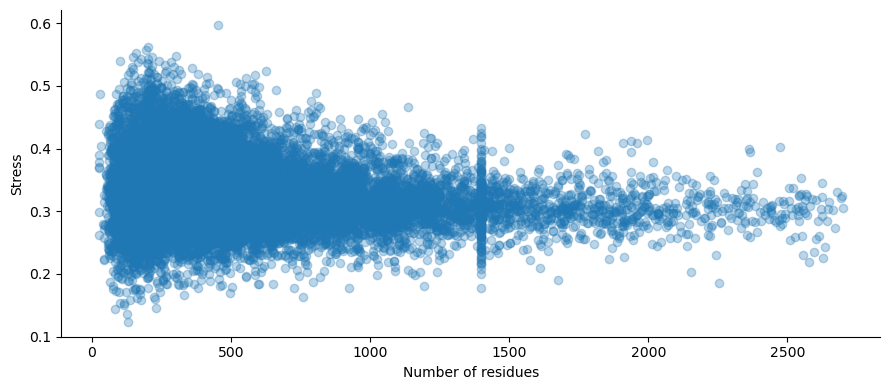

In [5]:
# Create figure with wider aspect ratio for better spread visualization
plt.figure(figsize=(9,4))

# Scatter plot: number of residues vs MDS stress
# alpha controls transparency to help with overplotting
plt.scatter(df['n_residues'], df['stress'], alpha=0.3)

# Axis labels
plt.xlabel('Number of residues')
plt.ylabel('Stress')

# Remove top and right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot
plt.tight_layout()
plt.show()

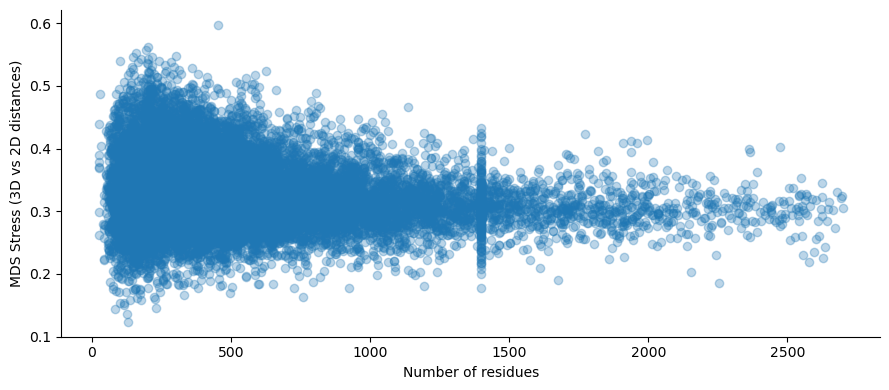

In [6]:
# Create figure with wide aspect ratio
plt.figure(figsize=(9,4))

# Scatter plot: number of residues vs Spearman correlation
# alpha reduces overplotting for dense regions
plt.scatter(df['n_residues'], df['stress'], alpha=0.3)

# Axis labels (corrected y-label)
plt.xlabel('Number of residues')
plt.ylabel('MDS Stress (3D vs 2D distances)')

# Remove top/right spines for cleaner aesthetics
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label clipping
plt.tight_layout()

# Display plot
plt.show()